TASK 2 - machine learning on dataset

1.Load cleaned_data.csv from Part 1. Define:

In [6]:
import pandas as pd

In [7]:
df= pd.read_csv('C:\\Users\\fcdhs\\Downloads\\india_housing_prices\\.venv\\cleaned_india_housing_prices.csv')

define the two targets

In [8]:
# regression target variable
y_reg = df['Price_in_Lakhs'].copy()

In [9]:
# classification target variable
y_clf = (y_reg > y_reg.median()).astype(int)  # Create a binary target variable for classification

choose and drop the right feature columns

In [10]:
drop_cols = ["ID", "Price_in_Lakhs", "Price_per_SqFt", "Locality", "Amenities"]
X_raw = df.drop(columns=drop_cols)
# why we dropped these columns:
# - "ID": This is likely a unique identifier for each row and does not provide predictive value for the target variable.
# - "Price_in_Lakhs": This is the target variable for regression, so it should not be included in the features.
# - "Price_per_SqFt": This is a derived feature that might be highly correlated with the target variable.
# - "Locality": This is a categorical variable that might not provide enough predictive value.
# - "Amenities": This is a categorical variable that might not provide enough predictive value. 


In [11]:
X_raw.head()  # display first 5 rows of the DataFrame after optimization

,State,City,Property_Type,BHK,Size_in_SqFt,Year_Built,Furnished_Status,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Facing,Owner_Type,Availability_Status
0,Tamil Nadu,Chennai,Apartment,1,4740,1990,Furnished,22,1,35,10,3,High,No,No,West,Owner,Ready_to_Move
1,Maharashtra,Pune,Independent House,3,2364,2008,Unfurnished,21,20,17,8,1,Low,No,Yes,North,Builder,Under_Construction
2,Punjab,Ludhiana,Apartment,2,3642,1997,Semi-furnished,19,27,28,9,8,Low,Yes,No,South,Broker,Ready_to_Move
3,Rajasthan,Jodhpur,Independent House,2,2741,1991,Furnished,21,26,34,5,7,High,Yes,Yes,North,Builder,Ready_to_Move
4,Rajasthan,Jaipur,Villa,4,4823,2002,Semi-furnished,3,2,23,4,9,Low,No,Yes,East,Builder,Ready_to_Move


2.Encode categorical columns: For each categorical column in X

label encoding

In [12]:
# encoding all categorical features using mapper functions
furnished_map = {"Unfurnished": 0, "Semi-furnished": 1, "Furnished": 2}
transport_map = {"Low": 0, "Medium": 1, "High": 2}
X_raw["Furnished_Status"] = X_raw["Furnished_Status"].map(furnished_map)
X_raw["Public_Transport_Accessibility"] = X_raw["Public_Transport_Accessibility"].map(transport_map)

for c in ["Parking_Space", "Security"]:
    X_raw[c] = X_raw[c].map({"No": 0, "Yes": 1})
X_raw["Availability_Status"] = X_raw["Availability_Status"].map(
    {"Ready_to_Move": 1, "Under_Construction": 0})

In [13]:
X_raw.head()  # display first 5 rows of the DataFrame after optimization

,State,City,Property_Type,BHK,Size_in_SqFt,Year_Built,Furnished_Status,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Facing,Owner_Type,Availability_Status
0,Tamil Nadu,Chennai,Apartment,1,4740,1990,2,22,1,35,10,3,2,0,0,West,Owner,1
1,Maharashtra,Pune,Independent House,3,2364,2008,0,21,20,17,8,1,0,0,1,North,Builder,0
2,Punjab,Ludhiana,Apartment,2,3642,1997,1,19,27,28,9,8,0,1,0,South,Broker,1
3,Rajasthan,Jodhpur,Independent House,2,2741,1991,2,21,26,34,5,7,2,1,1,North,Builder,1
4,Rajasthan,Jaipur,Villa,4,4823,2002,1,3,2,23,4,9,0,0,1,East,Builder,1


one hot encoding

In [14]:
nominal_cols = ["State", "City", "Property_Type", "Facing", "Owner_Type"]
X = pd.get_dummies(X_raw, columns=nominal_cols, drop_first=True)

In [15]:
X.head()  # display first 5 rows of the DataFrame after optimization

,BHK,Size_in_SqFt,Year_Built,Furnished_Status,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,...,City_Vijayawada,City_Vishakhapatnam,City_Warangal,Property_Type_Independent House,Property_Type_Villa,Facing_North,Facing_South,Facing_West,Owner_Type_Builder,Owner_Type_Owner
0,1,4740,1990,2,22,1,35,10,3,2,...,False,False,False,False,False,False,False,True,False,True
1,3,2364,2008,0,21,20,17,8,1,0,...,False,False,False,True,False,True,False,False,True,False
2,2,3642,1997,1,19,27,28,9,8,0,...,False,False,False,False,False,False,True,False,False,False
3,2,2741,1991,2,21,26,34,5,7,2,...,False,False,False,True,False,True,False,False,True,False
4,4,4823,2002,1,3,2,23,4,9,0,...,False,False,False,False,True,False,False,False,True,False


In [16]:
X.shape  # Display the shape of the DataFrame after optimization

(250000, 80)

3.Leak-free train-test split and scaling:

In [17]:
import sklearn

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [19]:
X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

scaler = StandardScaler()
scaler.fit(X_train)                       # <-- learn only from training data
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
X_train_scaled.shape, X_test_scaled.shape

((200000, 80), (50000, 80))

4.Regression model — Linear Regression

In [21]:
from sklearn.linear_model import LinearRegression
LR=LinearRegression()

In [22]:
LR.fit(X_train_scaled, y_reg_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](80,)","[-0.02,-0.23, 0.14,..., 0.51,-0.22,-0.17]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,254.6
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,80
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(60)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](80,)","[645.27,644.96,644.95,..., 0. , 0. , 0. ]"


In [23]:
y_pred_reg = LR.predict(X_test_scaled)

In [24]:
from sklearn.metrics import mean_squared_error, r2_score

In [25]:
print("Mean Squared Error:", mean_squared_error(y_reg_test, y_pred_reg))
print("R-squared:", r2_score(y_reg_test, y_pred_reg))

Mean Squared Error: 20053.350873183805
R-squared: -0.00036989349258464976


In [26]:
LR.coef_  # Display the coefficients of the linear regression model

array([-0.02216525, -0.22696672,  0.13872457, -0.04306886, -0.14498196,
        0.4297611 , -0.13872457,  0.00551881, -0.40213155, -0.02292944,
       -0.05539089,  0.67047295,  0.20910426, -0.25373834, -0.02424045,
       -0.1135514 , -0.23994259, -0.20885479,  0.16747151, -0.06651008,
        0.35848526, -0.10695754,  0.2078339 ,  0.03775396, -0.21433368,
       -0.19455924,  0.04123399,  0.33698873,  0.0158482 ,  0.18844057,
        0.01715476, -0.14705777, -0.27193585,  0.16629615,  0.2233092 ,
        0.14564751, -0.32359217,  0.05495593,  0.41237102, -0.44452948,
        0.56973948, -0.14867263, -0.04629578,  0.33223968,  0.50701964,
       -0.09857378, -0.0941231 , -0.54644555, -0.01051574,  0.06583725,
        0.15271347, -0.12314767, -0.09506008,  0.37038375, -0.05600099,
        0.11552814, -0.00154584,  0.11108229, -0.37574987,  0.33088357,
        0.20146924, -0.28848523,  0.14739498, -0.53983607,  0.236913  ,
        0.16488849,  0.03182091, -0.25863879,  0.4862419 , -0.52

In [27]:
# Get coefficients and feature names
coefficients = LR.coef_
feature_names = X.columns

# Create a dataframe with coefficients and feature names
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Abs_Coefficient': abs(coefficients)
}).sort_values('Abs_Coefficient', ascending=False).reset_index(drop=True)

# Display top 3 features with largest absolute coefficients
top_3 = coef_df.head(3)
print("Top 3 Features with Largest Absolute Coefficients:")
print(top_3[['Feature', 'Coefficient']])
print("\n" + "="*80)

# Interpretation
print("\nInterpretation:")
print("-" * 80)
for idx, row in top_3.iterrows():
    feature = row['Feature']
    coef = row['Coefficient']
    if coef > 0:
        print(f"\n{feature} (Coefficient: {coef:.6f})")
        print(f"  → POSITIVE: One unit increase in the scaled {feature} is associated with")
        print(f"    a {coef:.2f} unit increase in predicted Price_in_Lakhs.")
    else:
        print(f"\n{feature} (Coefficient: {coef:.6f})")
        print(f"  → NEGATIVE: One unit increase in the scaled {feature} is associated with")
        print(f"    a {abs(coef):.2f} unit DECREASE in predicted Price_in_Lakhs.")

Top 3 Features with Largest Absolute Coefficients:
               Feature  Coefficient
0             Security     0.670473
1  Property_Type_Villa    -0.610735
2        City_Dehradun     0.569739


Interpretation:
--------------------------------------------------------------------------------

Security (Coefficient: 0.670473)
  → POSITIVE: One unit increase in the scaled Security is associated with
    a 0.67 unit increase in predicted Price_in_Lakhs.

Property_Type_Villa (Coefficient: -0.610735)
  → NEGATIVE: One unit increase in the scaled Property_Type_Villa is associated with
    a 0.61 unit DECREASE in predicted Price_in_Lakhs.

City_Dehradun (Coefficient: 0.569739)
  → POSITIVE: One unit increase in the scaled City_Dehradun is associated with
    a 0.57 unit increase in predicted Price_in_Lakhs.


In [28]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

# ---- Ridge Regression on the same split/scaling ----
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_reg_train)
y_pred_ridge = ridge.predict(X_test_scaled)

# ---- Linear Regression predictions (reuse if already computed above) ----
y_pred_lr = LR.predict(X_test)

# ---- Metrics ----
mse_lr = mean_squared_error(y_reg_test, y_pred_lr)
r2_lr = r2_score(y_reg_test, y_pred_lr)

mse_ridge = mean_squared_error(y_reg_test, y_pred_ridge)
r2_ridge = r2_score(y_reg_test, y_pred_ridge)

# ---- Comparison table ----
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression (alpha=1.0)'],
    'MSE': [mse_lr, mse_ridge],
    'R2': [r2_lr, r2_ridge]
})

print("Model Comparison:")
print(comparison_df.to_string(index=False))

# ---- Coefficient comparison (optional but useful for your explanation) ----
ridge_coef_df = pd.DataFrame({
    'Feature': feature_names,
    'LR_Coefficient': LR.coef_,
    'Ridge_Coefficient': ridge.coef_
})
ridge_coef_df['Coef_Diff'] = (ridge_coef_df['LR_Coefficient'] - ridge_coef_df['Ridge_Coefficient']).abs()
ridge_coef_df = ridge_coef_df.sort_values('Coef_Diff', ascending=False).reset_index(drop=True)

print("\nCoefficient Comparison (Linear vs Ridge):")
print(ridge_coef_df)


Model Comparison:
                       Model           MSE         R2
           Linear Regression 227305.572156 -10.339235
Ridge Regression (alpha=1.0)  20053.350812  -0.000370

Coefficient Comparison (Linear vs Ridge):
                Feature  LR_Coefficient  Ridge_Coefficient     Coef_Diff
0            City_Surat        0.486242           0.486236  6.067928e-06
1         State_Gujarat       -0.208855          -0.208850  4.810173e-06
2   Property_Type_Villa       -0.610735          -0.610731  3.957531e-06
3           Facing_West        0.507930           0.507926  3.759140e-06
4              Security        0.670473           0.670470  3.354876e-06
..                  ...             ...                ...           ...
75          City_Indore        0.065837           0.065837  7.384405e-08
76                  BHK       -0.022165          -0.022165  6.301283e-08
77       City_Hyderabad       -0.010516          -0.010516  3.614280e-08
78      State_Jharkhand       -0.066510        

c:\Users\fcdhs\Downloads\india_housing_prices\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


4.Classification model — Logistic Regression

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, recall_score, precision_score, f1_score

In [30]:
log_reg = LogisticRegression(C=1.0, class_weight="balanced", max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_clf_train)
y_pred_clf = log_reg.predict(X_test_scaled)
y_proba_clf = log_reg.predict_proba(X_test_scaled)[:, 1]

In [31]:
cm = confusion_matrix(y_clf_test, y_pred_clf)
print(classification_report(y_clf_test, y_pred_clf))

              precision    recall  f1-score   support

           0       0.50      0.50      0.50     25000
           1       0.50      0.50      0.50     25000

    accuracy                           0.50     50000
   macro avg       0.50      0.50      0.50     50000
weighted avg       0.50      0.50      0.50     50000



In [32]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

ROC AUC Score: 0.4994


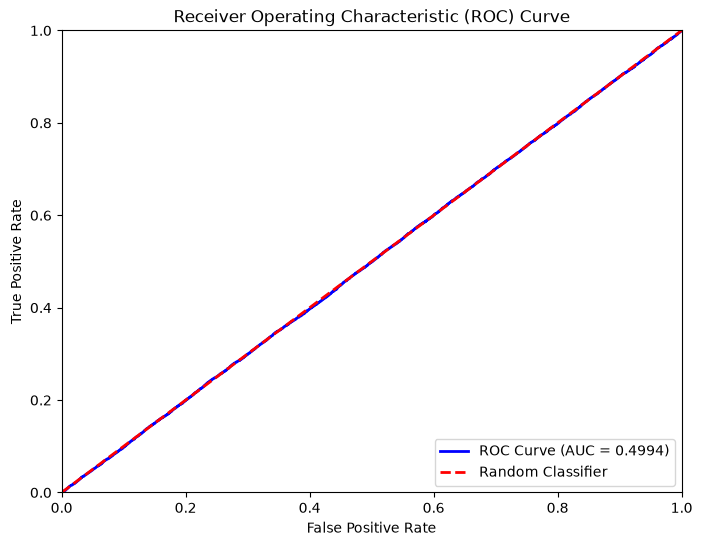

In [33]:
fpr, tpr, thresholds = roc_curve(y_clf_test, y_proba_clf)
auc_val = roc_auc_score(y_clf_test, y_proba_clf)
print(f"ROC AUC Score: {auc_val:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {auc_val:.4f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


Decision-threshold sensitivity

In [34]:
#threshold sensitivity analysis
thresholds = [0.3,0.4, 0.5,0.6, 0.7]
for threshold in thresholds:
    y_pred_threshold = (y_proba_clf >= threshold).astype(int)
    cm_threshold = confusion_matrix(y_clf_test, y_pred_threshold)
    print(f"\nThreshold: {threshold}")
    print("Confusion Matrix:")
    print(cm_threshold)
    print(classification_report(y_clf_test, y_pred_threshold))


Threshold: 0.3
Confusion Matrix:
[[    0 25000]
 [    0 25000]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     25000
           1       0.50      1.00      0.67     25000

    accuracy                           0.50     50000
   macro avg       0.25      0.50      0.33     50000
weighted avg       0.25      0.50      0.33     50000


Threshold: 0.4
Confusion Matrix:
[[    0 25000]
 [    0 25000]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     25000
           1       0.50      1.00      0.67     25000

    accuracy                           0.50     50000
   macro avg       0.25      0.50      0.33     50000
weighted avg       0.25      0.50      0.33     50000


Threshold: 0.5
Confusion Matrix:
[[12527 12473]
 [12548 12452]]
              precision    recall  f1-score   support

           0       0.50      0.50      0.50     25000
           1       0.50      0.50      0.5

c:\Users\fcdhs\Downloads\india_housing_prices\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\fcdhs\Downloads\india_housing_prices\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\fcdhs\Downloads\india_housing_prices\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

6.Regularization experiment on Logistic Regression

In [35]:
#regularization experiment on logistic regression(c_values)
c_values = [0.001, 0.01, 0.1, 1, 10, 100]
for c in c_values:
    log_reg_c = LogisticRegression(C=c, class_weight="balanced", max_iter=1000, random_state=42)
    log_reg_c.fit(X_train_scaled, y_clf_train)
    y_pred_c = log_reg_c.predict(X_test_scaled)
    print(f"\nC Value: {c}")
    print(classification_report(y_clf_test, y_pred_c))



C Value: 0.001
              precision    recall  f1-score   support

           0       0.50      0.50      0.50     25000
           1       0.50      0.50      0.50     25000

    accuracy                           0.50     50000
   macro avg       0.50      0.50      0.50     50000
weighted avg       0.50      0.50      0.50     50000


C Value: 0.01
              precision    recall  f1-score   support

           0       0.50      0.50      0.50     25000
           1       0.50      0.50      0.50     25000

    accuracy                           0.50     50000
   macro avg       0.50      0.50      0.50     50000
weighted avg       0.50      0.50      0.50     50000


C Value: 0.1
              precision    recall  f1-score   support

           0       0.50      0.50      0.50     25000
           1       0.50      0.50      0.50     25000

    accuracy                           0.50     50000
   macro avg       0.50      0.50      0.50     50000
weighted avg       0.50      

7.Bootstrap confidence interval for AUC difference

In [36]:
#Bootstrap confidence interval for AUC difference
import numpy as np
from sklearn.utils import resample
np.random.seed(42)  # For reproducibility
diffs=[]
for i in range(500):
    # Resample the test set with replacement
    X_resampled, y_resampled = resample(X_test_scaled, y_clf_test, replace=True, n_samples=len(y_clf_test))
    
    # Predict probabilities for the resampled data
    y_proba_resampled = log_reg.predict_proba(X_resampled)[:, 1]
    
    # Calculate AUC for the resampled data
    auc_resampled = roc_auc_score(y_resampled, y_proba_resampled)
    
    # Store the difference from the original AUC
    diffs.append(auc_resampled - auc_val)
    
# Calculate the 95% confidence interval for the AUC difference
ci_lower = np.percentile(diffs, 2.5)
ci_upper = np.percentile(diffs, 97.5)
print(f"95% Confidence Interval for AUC Difference: [{ci_lower:.4f}, {ci_upper:.4f}]")


95% Confidence Interval for AUC Difference: [-0.0050, 0.0048]


make csv file for task 3

In [37]:
# X_train_scaled
pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns  
).to_csv("X_train_scaled.csv", index=False)

In [38]:
# X_test_scaled
pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns
).to_csv("X_test_scaled.csv", index=False)


In [39]:
# y_clf_train
y_clf_train.to_csv("y_clf_train.csv", index=False)

In [40]:
# y_clf_test
y_clf_test.to_csv("y_clf_test.csv", index=False)

In [41]:
# x_train
X_train.to_csv("x_train.csv", index=False)

In [44]:
# x_test
X_test.to_csv("x_test.csv", index=False)

In [45]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)
print(y_clf_train.shape)
print(y_clf_test.shape)
print(X_train.shape)
print(X_test.shape)

(200000, 80)
(50000, 80)
(200000,)
(50000,)
(200000, 80)
(50000, 80)
